I am going to copy the functions for both the Jacobi and Gauss-Seidel methods from CH6. I will then reference from HW3 to do the plots.

-BEGIN-

In [26]:
import numpy as np
import time
import matplotlib.pyplot as plt

def jacobi(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    for k in range(max_iterations):
        x_new = np.zeros_like(x)
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]
        # Check for convergence
        if np.linalg.norm(x_new - x, ord=np.inf) < tol:
            return x_new, k
        x = x_new
    return x, max_iterations


def gauss_seidel(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    for k in range(max_iterations):
        x_new = x.copy()
        for i in range(n):
            s1 = sum(A[i][j] * x_new[j] for j in range(i)) # Using already updated values
            s2 = sum(A[i][j] * x[j] for j in range(i + 1, n)) # Using old values
            x_new[i] = (b[i] - s1 - s2) / A[i][i]
        # Check for convergence
        if np.linalg.norm(x_new - x, ord=np.inf) < tol:
            return x_new, k
        x = x_new
    return x, max_iterations




In [27]:
A = np.array([[3, -0.1, -0.2],
             [0.1, 7, -0.3],
             [0.3, -0.2, 10]])
b = np.array([7.85, -19.3, 71.4])
x0 = np.zeros_like(b)
tol = 1e-3
max_iterations = 100

print(jacobi(A, b, x0, tol, max_iterations))
print(gauss_seidel(A, b, x0, tol, max_iterations))
print("\n")

tol = 1e-6
max_iterations = 100
print(jacobi(A, b, x0, tol, max_iterations))
print(gauss_seidel(A, b, x0, tol, max_iterations))
print("\n")

tol = 1e-9
max_iterations = 100

print(jacobi(A, b, x0, tol, max_iterations))
print(gauss_seidel(A, b, x0, tol, max_iterations))

(array([ 3.0000225 , -2.50000266,  6.99998104]), 3)
(array([ 3.00000035, -2.50000004,  6.99999999]), 3)


(array([ 3. , -2.5,  7. ]), 6)
(array([ 3. , -2.5,  7. ]), 4)


(array([ 3. , -2.5,  7. ]), 8)
(array([ 3. , -2.5,  7. ]), 6)


The Jacobian needs more iterations in order to converge compared to the Gauss-Seidel method

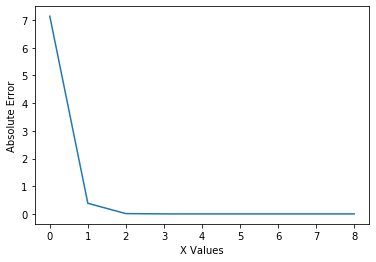

In [31]:
def jacobiPlot(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    yError = [] # Added a list for errors
    iterationNumber = [] # Added a list for the corresponding iteration
    for k in range(max_iterations):
        x_new = np.zeros_like(x)
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]
        # Check for convergence
        absError = abs(np.linalg.norm(x_new - x, ord = np.inf))
        yError.append(absError)
        iterationNumber.append(k)
        if np.linalg.norm(x_new - x, ord=np.inf) < tol: # I think this could be used for error
            return x_new, k, yError, iterationNumber
        x = x_new
    return x, max_iterations, yError, iterationNumber


A = np.array([[3, -0.1, -0.2],
             [0.1, 7, -0.3],
             [0.3, -0.2, 10]])
b = np.array([7.85, -19.3, 71.4])
x0 = np.zeros_like(b)
tol = 1e-9
max_iterations = 100


standin1, standin2, yAxis, xAxis = jacobiPlot(A, b, x0, tol, max_iterations)

plt.plot(xAxis, yAxis)
plt.xlabel("X Values")
plt.ylabel("Absolute Error")
plt.show() 

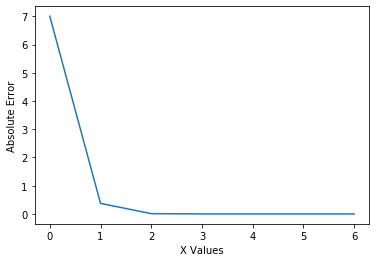

In [32]:
def gauss_seidelPlot(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    error = [] # Created list for error
    iterationNum = [] # Created List for corresponding iteration
    for k in range(max_iterations):
        x_new = x.copy()
        for i in range(n):
            s1 = sum(A[i][j] * x_new[j] for j in range(i)) # Using already updated values
            s2 = sum(A[i][j] * x[j] for j in range(i + 1, n)) # Using old values
            x_new[i] = (b[i] - s1 - s2) / A[i][i]
        absError = abs(np.linalg.norm(x_new - x, ord=np.inf))
        error.append(absError)
        iterationNum.append(k)
        # Check for convergence
        if np.linalg.norm(x_new - x, ord=np.inf) < tol:
            return x_new, k, error, iterationNum
        x = x_new
    return x, max_iterations, error, iterationNum

A = np.array([[3, -0.1, -0.2],
             [0.1, 7, -0.3],
             [0.3, -0.2, 10]])
b = np.array([7.85, -19.3, 71.4])
x0 = np.zeros_like(b)
tol = 1e-9
max_iterations = 100


standin1, standin2, yAxis, xAxis = gauss_seidelPlot(A, b, x0, tol, max_iterations)
plt.plot(xAxis, yAxis)
plt.xlabel("X Values")
plt.ylabel("Absolute Error")
plt.show() 

A decrease in tolerance usually corresponds to an increase in the number of iterations needed for both methods to converge. 